In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# for converting to html and viewing, then converting to pdf. Run this in terminal from the directory containing P1.ipynb
# jupyter nbconvert P1.ipynb --to html
# open P1.html

In [19]:
sz = qt.sigmaz()
sx = qt.sigmax()

def evolve_state(initial_state, times, delta, omega_d = 1, expect_ops = None):
    H = -0.5 * delta * sz + 0.5 * omega_d * sx
    result = qt.sesolve(H, initial_state, times, e_ops=expect_ops)
    return result

def projector_onto_states(states):
    # states: list of Qobj state vectors
    P = 0 * (states[0] * states[0].dag())   # zero operator with correct type/dims
    for psi in states:
        P += psi * psi.dag()
    return P

def P_01(tau, Delta_OmegaDrive_ratio):
    # compute the probability of being in the excited state after time tau, given detuning to drive ratio Delta_OmegaDrive_ratio. We started in the ground state at t=0. tau = t * omega_drive
    Omega_R = np.sqrt(1 + Delta_OmegaDrive_ratio**2) # Rabi frequency normalized to omega_drive
    P_01 = (1/(1 + Delta_OmegaDrive_ratio**2)) * (np.sin(Omega_R * tau / 2))**2
    return P_01
def P_00(tau, Delta_OmegaDrive_ratio):
    # compute the probability of being in the ground state after time tau, given detuning to drive ratio Delta_OmegaDrive_ratio. We started in the ground state at t=0. tau = t * omega_drive
    return 1 - P_01(tau, Delta_OmegaDrive_ratio)

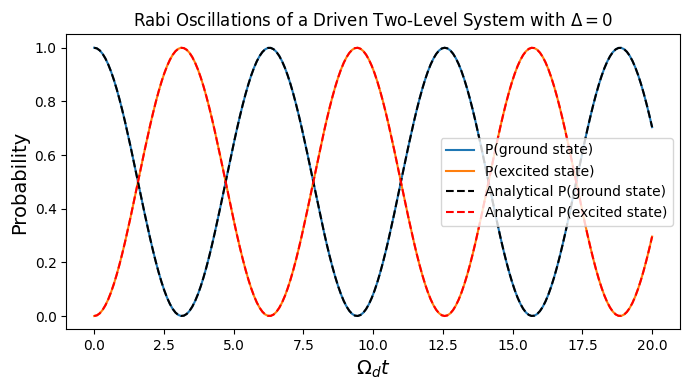

In [20]:
state_0 = qt.basis(2, 0) # ground state
state_1 = qt.basis(2, 1) # excited state

tau = np.linspace(0, 20, 200) # units of 1/omega_d
delta = 0 # detuning in units of omega_d
expect_ops = [projector_onto_states([state_0]), projector_onto_states([state_1])]
result = evolve_state(state_0, tau, delta, expect_ops=expect_ops)

plt.figure(figsize=(7, 4))
plt.plot(tau, result.expect[0], label='P(ground state)')
plt.plot(tau, result.expect[1], label='P(excited state)')
plt.plot(tau, P_00(tau, delta), 'k--', label='Analytical P(ground state)')
plt.plot(tau, P_01(tau, delta), 'r--', label='Analytical P(excited state)')
plt.xlabel(r'$\Omega_d t$', fontsize=14)
plt.ylabel('Probability', fontsize=14)
plt.title(r'Rabi Oscillations of a Driven Two-Level System with $\Delta=0$')
plt.legend()
plt.tight_layout()
plt.show()

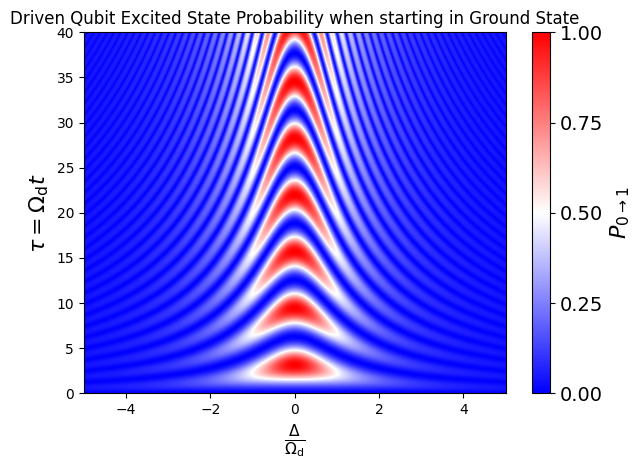

In [21]:
num_points = 1000
tau_array = np.linspace(0, 40, num_points)
Delta_OmegaDrive_max = 5
Delta_OmegaDrive_ratio_array = np.linspace(-Delta_OmegaDrive_max, Delta_OmegaDrive_max, num_points)

P_01_matrix = np.zeros((num_points, num_points))

for i, Delta_OmegaDrive_ratio in enumerate(Delta_OmegaDrive_ratio_array):
    result = evolve_state(state_0, tau_array, Delta_OmegaDrive_ratio, expect_ops=[projector_onto_states([state_1])])
    P_01_matrix[:,i] = result.expect[0] # times are columns, detuning ratios are rows

Delta_OmegaDrive_ratio_meshgrid, tau_meshgrid = np.meshgrid(Delta_OmegaDrive_ratio_array, tau_array)

plt.figure()
plt.contourf(Delta_OmegaDrive_ratio_array, tau_array, P_01_matrix, levels=500, cmap='bwr')

cbar = plt.colorbar()
cbar.set_label(r'$P_{0 \to 1}$', fontsize=16)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.ax.tick_params(labelsize=14) 

plt.xlabel(r'$\frac{\Delta}{\Omega_{\mathrm{d}}}$', fontsize=16)
plt.ylabel(r'$\tau = \Omega_{\mathrm{d}} t$', fontsize=16)
plt.title('Driven Qubit Excited State Probability when starting in Ground State')
plt.tight_layout()
plt.show()
